Google_Carbon_Free_Data_Center

In [1]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
pd.set_option("display.max_columns", None)


In [ ]:
# Load the Datasets

In [2]:
HERE = Path.cwd()

state_region = pd.read_csv(HERE / "state_region.csv")
renewables   = pd.read_csv(HERE / "renewable_energy.csv")
costs        = pd.read_csv(HERE / "electricity_cost.csv")
connectivity = pd.read_csv(HERE / "connectivity.csv")
gcp_regions  = pd.read_csv(HERE / "google_cloud_regions.csv")
incentives   = pd.read_csv(HERE / "incentives.csv")

connectivity["near_submarine_cable_landing"] = connectivity["near_submarine_cable_landing"].astype(bool)

state_region.head()

,state,grid_region,lat,lon
0,Gujarat,Western,23.22,72.68
1,Rajasthan,Northern,26.91,75.79
2,Tamil Nadu,Southern,13.08,80.27
3,Karnataka,Southern,12.97,77.59
4,Maharashtra,Western,18.52,73.86


In [ ]:
# Merge into one working table

In [3]:
df = (
    state_region
    .merge(renewables, on="state", how="left")
    .merge(costs, on="state", how="left")
    .merge(connectivity, on="state", how="left")
    .merge(incentives, on="state", how="left")
)

missing = df[df.isna().any(axis=1)]
if not missing.empty:
    raise ValueError(f"Missing data for states: {missing['state'].tolist()}")

print(f"{len(df)} candidate states loaded.")
df.head()


23 candidate states loaded.


,state,grid_region,lat,lon,re_share_2024_pct,re_growth_per_yr_pct,industrial_tariff_inr_per_kwh,near_submarine_cable_landing,incentive_inr_per_kwh
0,Gujarat,Western,23.22,72.68,46.0,3.2,6.6,True,0.55
1,Rajasthan,Northern,26.91,75.79,52.0,3.4,7.0,False,0.60
2,Tamil Nadu,Southern,13.08,80.27,48.0,3.0,7.6,True,0.50
3,Karnataka,Southern,12.97,77.59,61.0,2.6,7.9,False,0.45
4,Maharashtra,Western,18.52,73.86,31.0,2.4,8.4,True,0.35


In [ ]:
# Helper Function

In [40]:
def normalize(series: pd.Series, invert: bool = False) -> pd.Series:
    """Min-max normalize a column to 0-1. invert=True means lower raw value -> higher score
    (used for cost and distance, where lower is better)."""
    s = series.astype(float)
    rng = s.max() - s.min()
    if rng == 0:
        out = pd.Series(0.5, index=s.index)
    else:
        out = (s - s.min()) / rng
    return 1 - out if invert else out


def haversine_km(lat1, lon1, lat2, lon2) -> float:
    """Great-circle distance between two lat/lon points, in km."""
    R = 6371.0
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlmb = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dlmb / 2) ** 2
    return 2 * R * math.asin(math.sqrt(a))


In [ ]:
# Forecast renewable share to a target year

In [5]:
def forecast_renewable_share(df, target_year, base_year=2024):
    df = df.copy()
    years_ahead = target_year - base_year
    df["re_share"] = np.minimum(95.0, df["re_share_2024_pct"] + df["re_growth_per_yr_pct"] * years_ahead)
    return df

In [ ]:
# Latency: Distance to nearest existing Google cloud India region

In [ ]:
Existing regions: Mumbai(asia-south1), Delhi NCR(asia-south2).States within ~150km of a major submarine cable landing station get a 30% effective distance discount.

In [ ]:
# Composite site selection score

In [33]:
def compute_composite_score(df, w_renewable, w_cost, w_latency):
    total = w_renewable + w_cost + w_latency
    w_renewable, w_cost, w_latency = w_renewable / total, w_cost / total, w_latency / total

    df = df.copy()
    df["re_score"] = normalize(df["re_share"])
    df["cost_score"] = normalize(df["industrial_tariff_inr_per_kwh"], invert=True)
    df["latency_score"] = normalize(df["effective_distance_km"], invert=True)
    df["composite_score"] = (
        w_renewable * df["re_score"] + w_cost * df["cost_score"] + w_latency * df["latency_score"]
    ) * 100
    df["composite_score"] = df["composite_score"].round(1)
    return df

SCENARIOS = {
    "balanced":       dict(w_renewable=0.50, w_cost=0.30, w_latency=0.20),
    "greenest":       dict(w_renewable=0.70, w_cost=0.15, w_latency=0.15),
    "cheapest":       dict(w_renewable=0.20, w_cost=0.60, w_latency=0.20),
    "lowest_latency": dict(w_renewable=0.20, w_cost=0.20, w_latency=0.60),
}


In [ ]:
# ROI Model

In [8]:
INDIA_GRID_EMISSION_FACTOR_TCO2_PER_MWH = 0.716   # CEA CO2 Baseline Database, all-India avg
CARBON_PRICE_INR_PER_TON = 4150                    # ~$50/ton @ ~INR 83/USD (illustrative)
CAPEX_INR_CRORE_PER_MW = 41.5                      # ~$5M/MW hyperscale DC rule of thumb
DEFAULT_UTILIZATION = 0.85                         # assumed IT load utilization

def compute_roi(df, mw_capacity, utilization=DEFAULT_UTILIZATION):
    df = df.copy()

    df["annual_energy_mwh"] = mw_capacity * 8760 * utilization

    avg_tariff = df["industrial_tariff_inr_per_kwh"].mean()
    df["energy_savings_inr"] = (avg_tariff - df["industrial_tariff_inr_per_kwh"]) * df["annual_energy_mwh"] * 1000

    df["emissions_avoided_tons"] = (df["re_share"] / 100) * df["annual_energy_mwh"] * INDIA_GRID_EMISSION_FACTOR_TCO2_PER_MWH
    df["carbon_savings_inr"] = df["emissions_avoided_tons"] * CARBON_PRICE_INR_PER_TON

    df["incentive_savings_inr"] = df["incentive_inr_per_kwh"] * df["annual_energy_mwh"] * 1000

    df["capex_inr_cr"] = CAPEX_INR_CRORE_PER_MW * mw_capacity
    capex_inr = df["capex_inr_cr"] * 1e7

    total_savings_inr = df["energy_savings_inr"] + df["carbon_savings_inr"] + df["incentive_savings_inr"]
    df["roi_pct"] = (total_savings_inr / capex_inr) * 100

    df["energy_savings_inr_cr"] = (df["energy_savings_inr"] / 1e7).round(2)
    df["carbon_savings_inr_cr"] = (df["carbon_savings_inr"] / 1e7).round(2)
    df["incentive_savings_inr_cr"] = (df["incentive_savings_inr"] / 1e7).round(2)
    df["roi_pct"] = df["roi_pct"].round(1)
    return df


In [ ]:
# Set the scenario , year and Data center size

In [36]:
YEAR = 2030
SCENARIO = "balanced"
MW_CAPACITY = 50

weights = SCENARIOS[SCENARIO]

scored = forecast_renewable_share(df, target_year=YEAR)
scored = attach_latency(scored, gcp_regions)   # Remove this line

scored = compute_composite_score(scored, **weights)
scored = compute_roi(scored, mw_capacity=MW_CAPACITY)

ranked = scored.sort_values("composite_score", ascending=False).reset_index(drop=True)
ranked.insert(0, "rank", ranked.index + 1)

ranked.head(10)

,rank,state,grid_region,lat,lon,re_share_2024_pct,re_growth_per_yr_pct,industrial_tariff_inr_per_kwh,near_submarine_cable_landing,incentive_inr_per_kwh,re_share,distance_km,nearest_gcp_region,effective_distance_km,re_score,cost_score,latency_score,composite_score,annual_energy_mwh,energy_savings_inr,emissions_avoided_tons,carbon_savings_inr,incentive_savings_inr,capex_inr_cr,roi_pct,energy_savings_inr_cr,carbon_savings_inr_cr,incentive_savings_inr_cr
0,1,Himachal Pradesh,Northern,31.10,77.17,82.0,1.0,5.5,False,0.65,88.0,276.467282,asia-south2,276.467282,1.000000,1.000000,0.810878,96.2,372300.0,6.361474e+08,234578.7840,9.735020e+08,241995000.0,2075.0,8.9,63.61,97.35,24.20
1,2,Jammu & Kashmir,Northern,34.08,74.80,66.0,1.1,5.8,False,0.55,72.6,649.363561,asia-south2,649.363561,0.785515,0.900000,0.555381,77.4,372300.0,5.244574e+08,193527.4968,8.031391e+08,204765000.0,2075.0,7.4,52.45,80.31,20.48
2,3,Rajasthan,Northern,26.91,75.79,52.0,3.4,7.0,False,0.60,72.4,235.348102,asia-south2,235.348102,0.782730,0.500000,0.839051,70.9,372300.0,7.769739e+07,192994.3632,8.009266e+08,223380000.0,2075.0,5.3,7.77,80.09,22.34
3,4,Gujarat,Western,23.22,72.68,46.0,3.2,6.6,True,0.55,65.2,461.247391,asia-south1,368.997913,0.682451,0.633333,0.747479,68.1,372300.0,2.266174e+08,173801.5536,7.212764e+08,204765000.0,2075.0,5.6,22.66,72.13,20.48
4,5,Uttarakhand,Northern,30.32,78.03,46.0,1.4,6.2,False,0.45,54.4,205.684564,asia-south2,205.684564,0.532033,0.766667,0.859376,66.8,372300.0,3.755374e+08,145012.3392,6.018012e+08,167535000.0,2075.0,5.5,37.55,60.18,16.75
5,6,Karnataka,Southern,12.97,77.59,61.0,2.6,7.9,False,0.45,76.6,845.169693,asia-south1,845.169693,0.841226,0.200000,0.421221,56.5,372300.0,-2.573726e+08,204190.1688,8.473892e+08,167535000.0,2075.0,3.7,-25.74,84.74,16.75
6,7,Andhra Pradesh,Southern,16.51,80.52,44.0,2.8,7.3,True,0.50,60.8,857.834263,asia-south1,686.267411,0.621170,0.400000,0.530096,53.7,372300.0,-3.399261e+07,162072.6144,6.726013e+08,186150000.0,2075.0,4.0,-3.40,67.26,18.61
7,8,Tamil Nadu,Southern,13.08,80.27,48.0,3.0,7.6,True,0.50,66.0,1033.238912,asia-south1,826.591130,0.693593,0.300000,0.433950,52.4,372300.0,-1.456826e+08,175934.0880,7.301265e+08,186150000.0,2075.0,3.7,-14.57,73.01,18.61
8,9,Madhya Pradesh,Western,23.26,77.41,33.0,2.4,7.2,False,0.40,47.4,595.665283,asia-south2,595.665283,0.434540,0.433333,0.592173,46.6,372300.0,3.237391e+06,126352.6632,5.243636e+08,148920000.0,2075.0,3.3,0.32,52.44,14.89
9,10,Maharashtra,Western,18.52,73.86,31.0,2.4,8.4,True,0.35,45.4,120.473289,asia-south1,96.378631,0.406685,0.033333,0.934269,40.0,372300.0,-4.435226e+08,121021.3272,5.022385e+08,130305000.0,2075.0,0.9,-44.35,50.22,13.03


In [10]:
import math
from pathlib import Path
import numpy as np
import pandas as pd

HERE = Path.cwd()

state_region = pd.read_csv(HERE / "state_region.csv")
renewables   = pd.read_csv(HERE / "renewable_energy.csv")
costs        = pd.read_csv(HERE / "electricity_cost.csv")
connectivity = pd.read_csv(HERE / "connectivity.csv")
gcp_regions  = pd.read_csv(HERE / "google_cloud_regions.csv")
incentives   = pd.read_csv(HERE / "incentives.csv")
connectivity["near_submarine_cable_landing"] = connectivity["near_submarine_cable_landing"].astype(bool)

df = (
    state_region
    .merge(renewables, on="state", how="left")
    .merge(costs, on="state", how="left")
    .merge(connectivity, on="state", how="left")
    .merge(incentives, on="state", how="left")
)

def normalize(series, invert=False):
    s = series.astype(float)
    rng = s.max() - s.min()
    out = pd.Series(0.5, index=s.index) if rng == 0 else (s - s.min()) / rng
    return 1 - out if invert else out

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlmb = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(p1)*math.cos(p2)*math.sin(dlmb/2)**2
    return 2 * R * math.asin(math.sqrt(a))

def forecast_renewable_share(df, target_year, base_year=2024):
    df = df.copy()
    years_ahead = target_year - base_year
    df["re_share"] = np.minimum(95.0, df["re_share_2024_pct"] + df["re_growth_per_yr_pct"] * years_ahead)
    return df

def attach_latency(df, gcp_regions):
    df = df.copy()
    def nearest(row):
        dists = {r["region_name"]: haversine_km(row["lat"], row["lon"], r["lat"], r["lon"])
                 for _, r in gcp_regions.iterrows()}
        best = min(dists, key=dists.get)
        return pd.Series({"distance_km": dists[best], "nearest_gcp_region": best})
    df = df.join(df.apply(nearest, axis=1))
    df["effective_distance_km"] = np.where(df["near_submarine_cable_landing"], df["distance_km"] * 0.7, df["distance_km"])
    return df

def compute_composite_score(df, w_renewable, w_cost, w_latency):
    total = w_renewable + w_cost + w_latency
    w_renewable, w_cost, w_latency = w_renewable/total, w_cost/total, w_latency/total
    df = df.copy()
    df["re_score"] = normalize(df["re_share"])
    df["cost_score"] = normalize(df["industrial_tariff_inr_per_kwh"], invert=True)
    df["latency_score"] = normalize(df["effective_distance_km"], invert=True)
    df["composite_score"] = (w_renewable*df["re_score"] + w_cost*df["cost_score"] + w_latency*df["latency_score"]) * 100
    df["composite_score"] = df["composite_score"].round(1)
    return df

SCENARIOS = {
    "balanced":       dict(w_renewable=0.50, w_cost=0.30, w_latency=0.20),
    "greenest":       dict(w_renewable=0.70, w_cost=0.15, w_latency=0.15),
    "cheapest":       dict(w_renewable=0.20, w_cost=0.60, w_latency=0.20),
    "lowest_latency": dict(w_renewable=0.20, w_cost=0.20, w_latency=0.60),
}

INDIA_GRID_EMISSION_FACTOR_TCO2_PER_MWH = 0.716
CARBON_PRICE_INR_PER_TON = 4150
CAPEX_INR_CRORE_PER_MW = 41.5
DEFAULT_UTILIZATION = 0.85

def compute_roi(df, mw_capacity, utilization=DEFAULT_UTILIZATION):
    df = df.copy()
    df["annual_energy_mwh"] = mw_capacity * 8760 * utilization
    avg_tariff = df["industrial_tariff_inr_per_kwh"].mean()
    df["energy_savings_inr"] = (avg_tariff - df["industrial_tariff_inr_per_kwh"]) * df["annual_energy_mwh"] * 1000
    df["emissions_avoided_tons"] = (df["re_share"]/100) * df["annual_energy_mwh"] * INDIA_GRID_EMISSION_FACTOR_TCO2_PER_MWH
    df["carbon_savings_inr"] = df["emissions_avoided_tons"] * CARBON_PRICE_INR_PER_TON
    df["incentive_savings_inr"] = df["incentive_inr_per_kwh"] * df["annual_energy_mwh"] * 1000
    df["capex_inr_cr"] = CAPEX_INR_CRORE_PER_MW * mw_capacity
    capex_inr = df["capex_inr_cr"] * 1e7
    total_savings_inr = df["energy_savings_inr"] + df["carbon_savings_inr"] + df["incentive_savings_inr"]
    df["roi_pct"] = (total_savings_inr / capex_inr) * 100
    df["roi_pct"] = df["roi_pct"].round(1)
    return df

# ---- CHANGE ME ----
YEAR = 2030
SCENARIO = "balanced"
MW_CAPACITY = 50
# -------------------

weights = SCENARIOS[SCENARIO]
scored = forecast_renewable_share(df, target_year=YEAR)
scored = attach_latency(scored, gcp_regions)
scored = compute_composite_score(scored, **weights)
scored = compute_roi(scored, mw_capacity=MW_CAPACITY)

ranked = scored.sort_values("composite_score", ascending=False).reset_index(drop=True)
ranked.insert(0, "rank", ranked.index + 1)
ranked.head(10)

,rank,state,grid_region,lat,lon,re_share_2024_pct,re_growth_per_yr_pct,industrial_tariff_inr_per_kwh,near_submarine_cable_landing,incentive_inr_per_kwh,re_share,distance_km,nearest_gcp_region,effective_distance_km,re_score,cost_score,latency_score,composite_score,annual_energy_mwh,energy_savings_inr,emissions_avoided_tons,carbon_savings_inr,incentive_savings_inr,capex_inr_cr,roi_pct
0,1,Himachal Pradesh,Northern,31.10,77.17,82.0,1.0,5.5,False,0.65,88.0,276.467282,Delhi NCR,276.467282,1.000000,1.000000,0.810878,96.2,372300.0,6.361474e+08,234578.7840,9.735020e+08,241995000.0,2075.0,8.9
1,2,Jammu & Kashmir,Northern,34.08,74.80,66.0,1.1,5.8,False,0.55,72.6,649.363561,Delhi NCR,649.363561,0.785515,0.900000,0.555381,77.4,372300.0,5.244574e+08,193527.4968,8.031391e+08,204765000.0,2075.0,7.4
2,3,Rajasthan,Northern,26.91,75.79,52.0,3.4,7.0,False,0.60,72.4,235.348102,Delhi NCR,235.348102,0.782730,0.500000,0.839051,70.9,372300.0,7.769739e+07,192994.3632,8.009266e+08,223380000.0,2075.0,5.3
3,4,Gujarat,Western,23.22,72.68,46.0,3.2,6.6,True,0.55,65.2,461.247391,Mumbai,322.873174,0.682451,0.633333,0.779082,68.7,372300.0,2.266174e+08,173801.5536,7.212764e+08,204765000.0,2075.0,5.6
4,5,Uttarakhand,Northern,30.32,78.03,46.0,1.4,6.2,False,0.45,54.4,205.684564,Delhi NCR,205.684564,0.532033,0.766667,0.859376,66.8,372300.0,3.755374e+08,145012.3392,6.018012e+08,167535000.0,2075.0,5.5
5,6,Karnataka,Southern,12.97,77.59,61.0,2.6,7.9,False,0.45,76.6,845.169693,Mumbai,845.169693,0.841226,0.200000,0.421221,56.5,372300.0,-2.573726e+08,204190.1688,8.473892e+08,167535000.0,2075.0,3.7
6,7,Andhra Pradesh,Southern,16.51,80.52,44.0,2.8,7.3,True,0.50,60.8,857.834263,Mumbai,600.483984,0.621170,0.400000,0.588872,54.8,372300.0,-3.399261e+07,162072.6144,6.726013e+08,186150000.0,2075.0,4.0
7,8,Tamil Nadu,Southern,13.08,80.27,48.0,3.0,7.6,True,0.50,66.0,1033.238912,Mumbai,723.267239,0.693593,0.300000,0.504745,53.8,372300.0,-1.456826e+08,175934.0880,7.301265e+08,186150000.0,2075.0,3.7
8,9,Madhya Pradesh,Western,23.26,77.41,33.0,2.4,7.2,False,0.40,47.4,595.665283,Delhi NCR,595.665283,0.434540,0.433333,0.592173,46.6,372300.0,3.237391e+06,126352.6632,5.243636e+08,148920000.0,2075.0,3.3
9,10,Maharashtra,Western,18.52,73.86,31.0,2.4,8.4,True,0.35,45.4,120.473289,Mumbai,84.331302,0.406685,0.033333,0.942523,40.2,372300.0,-4.435226e+08,121021.3272,5.022385e+08,130305000.0,2075.0,0.9


In [ ]:
# Ranking Table

In [11]:
ranked[["rank", "state", "grid_region", "re_share", "industrial_tariff_inr_per_kwh",
        "distance_km", "nearest_gcp_region", "composite_score"]]

,rank,state,grid_region,re_share,industrial_tariff_inr_per_kwh,distance_km,nearest_gcp_region,composite_score
0,1,Himachal Pradesh,Northern,88.0,5.5,276.467282,Delhi NCR,96.2
1,2,Jammu & Kashmir,Northern,72.6,5.8,649.363561,Delhi NCR,77.4
2,3,Rajasthan,Northern,72.4,7.0,235.348102,Delhi NCR,70.9
3,4,Gujarat,Western,65.2,6.6,461.247391,Mumbai,68.7
4,5,Uttarakhand,Northern,54.4,6.2,205.684564,Delhi NCR,66.8
5,6,Karnataka,Southern,76.6,7.9,845.169693,Mumbai,56.5
6,7,Andhra Pradesh,Southern,60.8,7.3,857.834263,Mumbai,54.8
7,8,Tamil Nadu,Southern,66.0,7.6,1033.238912,Mumbai,53.8
8,9,Madhya Pradesh,Western,47.4,7.2,595.665283,Delhi NCR,46.6
9,10,Maharashtra,Western,45.4,8.4,120.473289,Mumbai,40.2


In [ ]:
# ROI Table

In [37]:
roi_ranked = scored.sort_values("roi_pct", ascending=False)[
    ["state", "grid_region", "industrial_tariff_inr_per_kwh", "re_share",
     "emissions_avoided_tons", "energy_savings_inr_cr", "carbon_savings_inr_cr",
     "incentive_savings_inr_cr", "capex_inr_cr", "roi_pct"]
]
roi_ranked


,state,grid_region,industrial_tariff_inr_per_kwh,re_share,emissions_avoided_tons,energy_savings_inr_cr,carbon_savings_inr_cr,incentive_savings_inr_cr,capex_inr_cr,roi_pct
15,Himachal Pradesh,Northern,5.5,88.0,234578.7840,63.61,97.35,24.20,2075.0,8.9
17,Jammu & Kashmir,Northern,5.8,72.6,193527.4968,52.45,80.31,20.48,2075.0,7.4
0,Gujarat,Western,6.6,65.2,173801.5536,22.66,72.13,20.48,2075.0,5.6
16,Uttarakhand,Northern,6.2,54.4,145012.3392,37.55,60.18,16.75,2075.0,5.5
1,Rajasthan,Northern,7.0,72.4,192994.3632,7.77,80.09,22.34,2075.0,5.3
5,Andhra Pradesh,Southern,7.3,60.8,162072.6144,-3.40,67.26,18.61,2075.0,4.0
18,Chhattisgarh,Western,6.0,22.6,60244.0968,45.00,25.00,11.17,2075.0,3.9
2,Tamil Nadu,Southern,7.6,66.0,175934.0880,-14.57,73.01,18.61,2075.0,3.7
3,Karnataka,Southern,7.9,76.6,204190.1688,-25.74,84.74,16.75,2075.0,3.7
7,Madhya Pradesh,Western,7.2,47.4,126352.6632,0.32,52.44,14.89,2075.0,3.3


In [23]:
def compute_roi(df, mw_capacity, utilization=DEFAULT_UTILIZATION):
    df = df.copy()
    df["annual_energy_mwh"] = mw_capacity * 8760 * utilization

    avg_tariff = df["industrial_tariff_inr_per_kwh"].mean()
    df["energy_savings_inr"] = (avg_tariff - df["industrial_tariff_inr_per_kwh"]) * df["annual_energy_mwh"] * 1000

    df["emissions_avoided_tons"] = (df["re_share"] / 100) * df["annual_energy_mwh"] * INDIA_GRID_EMISSION_FACTOR_TCO2_PER_MWH
    df["carbon_savings_inr"] = df["emissions_avoided_tons"] * CARBON_PRICE_INR_PER_TON

    df["incentive_savings_inr"] = df["incentive_inr_per_kwh"] * df["annual_energy_mwh"] * 1000

    df["capex_inr_cr"] = CAPEX_INR_CRORE_PER_MW * mw_capacity
    capex_inr = df["capex_inr_cr"] * 1e7

    total_savings_inr = df["energy_savings_inr"] + df["carbon_savings_inr"] + df["incentive_savings_inr"]
    df["roi_pct"] = (total_savings_inr / capex_inr) * 100

    # these three lines were missing before — they're what roi_ranked needs
    df["energy_savings_inr_cr"] = (df["energy_savings_inr"] / 1e7).round(2)
    df["carbon_savings_inr_cr"] = (df["carbon_savings_inr"] / 1e7).round(2)
    df["incentive_savings_inr_cr"] = (df["incentive_savings_inr"] / 1e7).round(2)
    df["roi_pct"] = df["roi_pct"].round(1)
    return df
    roi_ranked(10)

In [21]:
# Charts

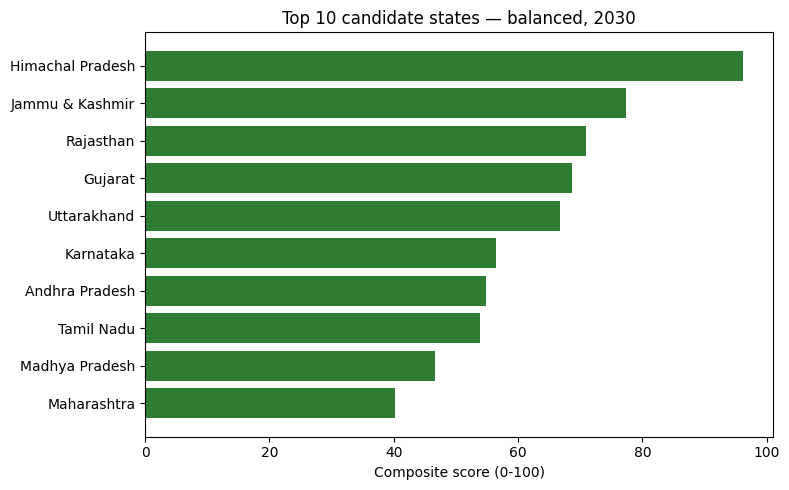

In [15]:
top = ranked.head(10).sort_values("composite_score")
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top["state"], top["composite_score"], color="#2e7d32")
ax.set_xlabel("Composite score (0-100)")
ax.set_title(f"Top 10 candidate states — {SCENARIO}, {YEAR}")
plt.tight_layout()
plt.show()


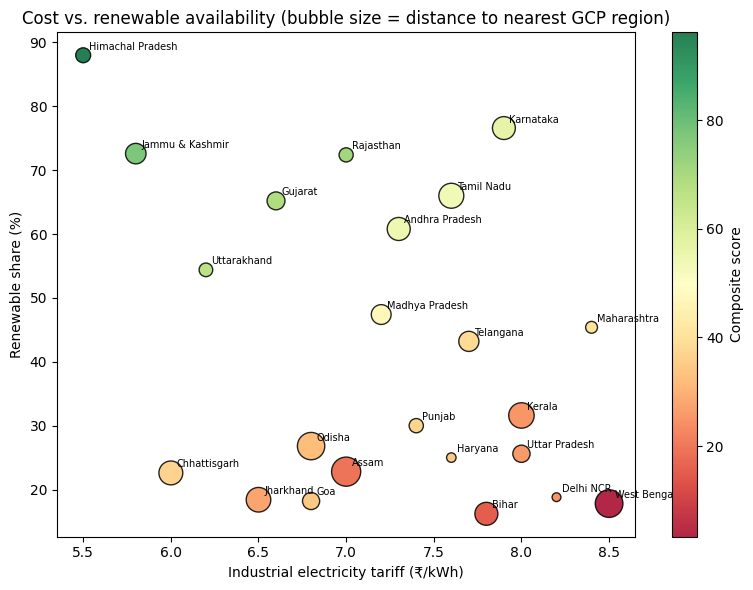

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
sizes = (ranked["distance_km"] / ranked["distance_km"].max()) * 400 + 40
sc = ax.scatter(ranked["industrial_tariff_inr_per_kwh"], ranked["re_share"],
                 s=sizes, c=ranked["composite_score"], cmap="RdYlGn", edgecolors="k", alpha=0.85)
for _, r in ranked.iterrows():
    ax.annotate(r["state"], (r["industrial_tariff_inr_per_kwh"], r["re_share"]), fontsize=7,
                xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Industrial electricity tariff (₹/kWh)")
ax.set_ylabel("Renewable share (%)")
ax.set_title("Cost vs. renewable availability (bubble size = distance to nearest GCP region)")
fig.colorbar(sc, ax=ax, label="Composite score")
plt.tight_layout()
plt.show()

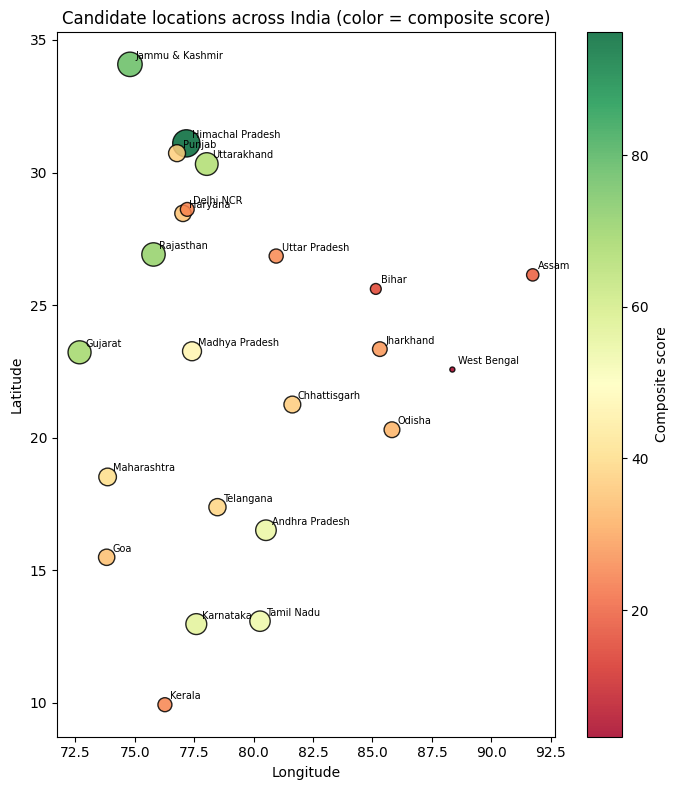

In [17]:
fig, ax = plt.subplots(figsize=(7, 8))
sc = ax.scatter(ranked["lon"], ranked["lat"], s=ranked["composite_score"] * 4,
                 c=ranked["composite_score"], cmap="RdYlGn", edgecolors="k", alpha=0.85)
for _, r in ranked.iterrows():
    ax.annotate(r["state"], (r["lon"], r["lat"]), fontsize=7, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Candidate locations across India (color = composite score)")
fig.colorbar(sc, ax=ax, label="Composite score")
plt.tight_layout()
plt.show()


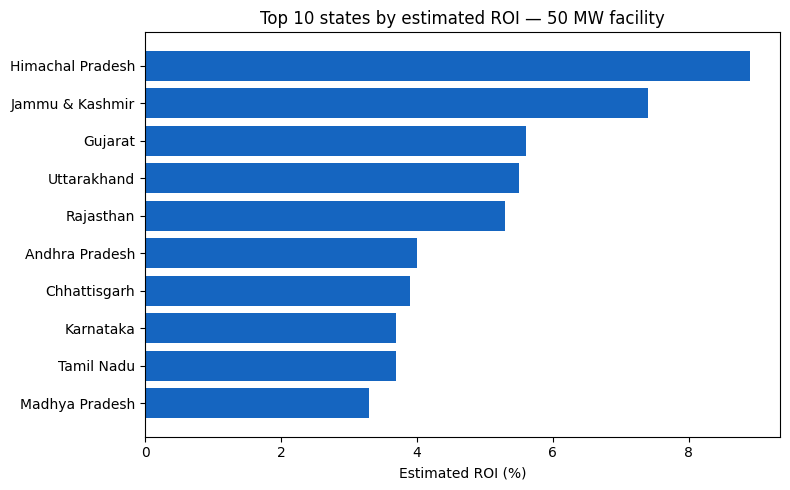

In [38]:
top_roi = roi_ranked.head(10).sort_values("roi_pct")
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_roi["state"], top_roi["roi_pct"], color="#1565c0")
ax.set_xlabel("Estimated ROI (%)")
ax.set_title(f"Top 10 states by estimated ROI — {MW_CAPACITY} MW facility")
plt.tight_layout()
plt.show()


In [ ]:
# 2024 to 2030 renewable outlook ( Top 8 states)

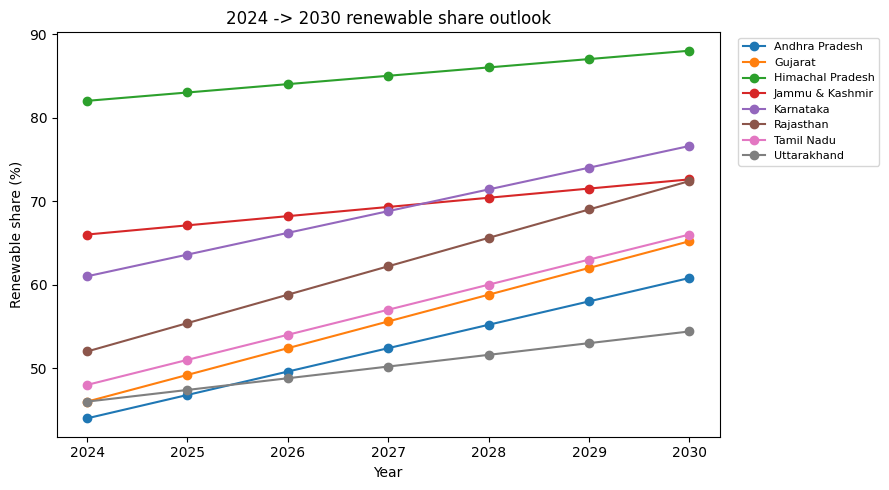

In [39]:
top_states = ranked.head(8)["state"].tolist()
years = list(range(2024, 2031))
rows = []
for _, r in df[df["state"].isin(top_states)].iterrows():
    for y in years:
        rows.append({
            "state": r["state"], "year": y,
            "re_share": min(95.0, r["re_share_2024_pct"] + r["re_growth_per_yr_pct"] * (y - 2024)),
        })
trend = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 5))
for state, grp in trend.groupby("state"):
    ax.plot(grp["year"], grp["re_share"], marker="o", label=state)
ax.set_xlabel("Year")
ax.set_ylabel("Renewable share (%)")
ax.set_title("2024 -> 2030 renewable share outlook")
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()